In [1]:
import pandas as pd
from sqlalchemy import create_engine

In [2]:
DB_USER = 'Aidar'
DB_PASS = ''
DB_HOST = 'localhost'
DB_PORT = '5432'
DB_NAME = 'german_credit'

In [3]:
engine = create_engine(f'postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}')

In [4]:
df = pd.read_sql('SELECT * FROM model_dataset', engine)


In [5]:
print(f'Загружено строк: {len(df)}, столбцов: {df.shape[1]}')
df.head()

Загружено строк: 1000, столбцов: 19


,age_bin_bad_rate,duration_bin_bad_rate,credit_amount_bin_bad_rate,installment_rate,existing_credits_count,liable_people_count,checking_bad_rate,credit_history_bad_rate,purpose_bad_rate,savings_account_bonds_bad_rate,housing_bad_rate,job_bad_rate,personal_status_sex_bad_rate,other_debtors_guarantors_bad_rate,property_bad_rate,other_installment_plans_bad_rate,telephone_bad_rate,foreign_worker_bad_rate,target
0,0.2727,0.3085,0.2298,4,1,1,0.4927,0.3189,0.2214,0.3599,0.3911,0.2800,0.2664,0.2999,0.2128,0.4101,0.3138,0.3074,1
1,0.3686,0.1561,0.2298,4,1,1,0.3903,0.5714,0.2214,0.3599,0.2609,0.2800,0.2664,0.2999,0.2128,0.4043,0.3138,0.3074,1
2,0.2576,0.3399,0.2298,4,1,1,0.2222,0.3189,0.2214,0.3599,0.2609,0.2952,0.2664,0.4390,0.2128,0.4043,0.3138,0.3074,2
3,0.2576,0.3085,0.3814,4,2,2,0.1168,0.1706,0.3204,0.1250,0.2609,0.2800,0.2664,0.2999,0.2128,0.4043,0.2797,0.3074,1
4,0.3686,0.3085,0.2298,4,1,1,0.3903,0.3189,0.3803,0.3599,0.2609,0.2800,0.2664,0.2999,0.2128,0.4043,0.3138,0.3074,2


In [6]:
y = df['target'].map({1: 0, 2: 1})

X = df.drop('target', axis=1)

print(f'Размерность X: {X.shape}')
print(f'Распределение классов:\n{y.value_counts()}')

Размерность X: (1000, 18)
Распределение классов:
target
0    700
1    300
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} строк, Test: {X_test.shape[0]} строк')

Train: 700 строк, Test: 300 строк


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')


In [9]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [10]:
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print("\nОтчёт о классификации:")
print(classification_report(y_test, y_pred, target_names=['Good', 'Bad']))

Матрица ошибок:
[[199  11]
 [ 54  36]]

Отчёт о классификации:
              precision    recall  f1-score   support

        Good       0.79      0.95      0.86       210
         Bad       0.77      0.40      0.53        90

    accuracy                           0.78       300
   macro avg       0.78      0.67      0.69       300
weighted avg       0.78      0.78      0.76       300



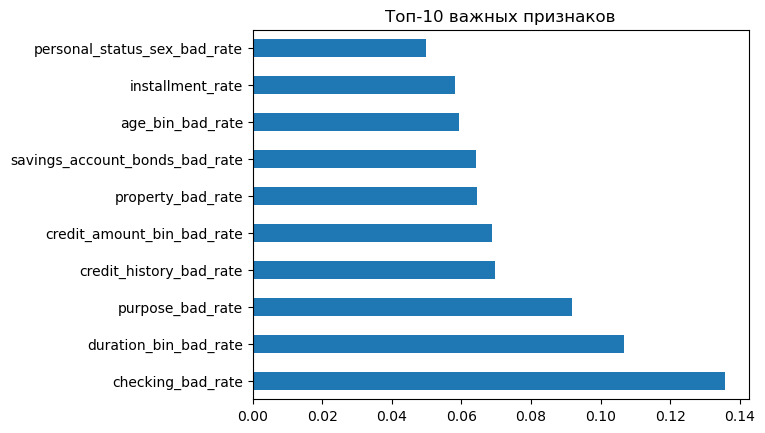

In [11]:
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', title='Топ-10 важных признаков');

In [12]:
y_proba = model.predict_proba(X_test)[:, 1]


In [13]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)


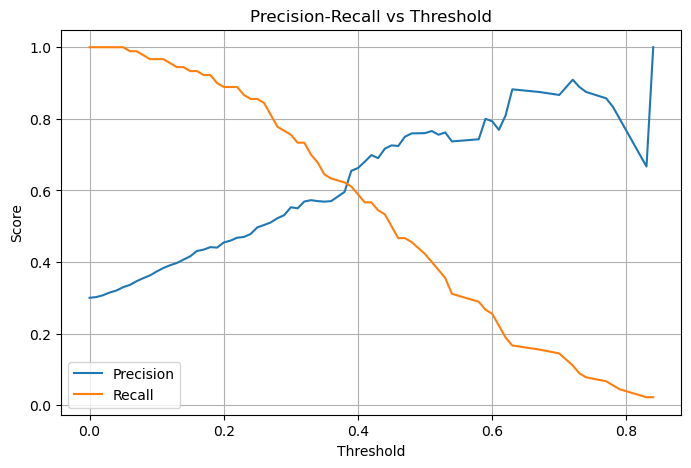

In [14]:
plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.grid()
plt.show()

In [15]:
threshold = 0.4

y_pred_custom = (y_proba >= threshold).astype(int)

print("Матрица ошибок при пороге 0.4:")
print(confusion_matrix(y_test, y_pred_custom))
print("\nОтчёт о классификации при пороге 0.4:")
print(classification_report(y_test, y_pred_custom, target_names=['Good', 'Bad']))

Матрица ошибок при пороге 0.4:
[[183  27]
 [ 37  53]]

Отчёт о классификации при пороге 0.4:
              precision    recall  f1-score   support

        Good       0.83      0.87      0.85       210
         Bad       0.66      0.59      0.62        90

    accuracy                           0.79       300
   macro avg       0.75      0.73      0.74       300
weighted avg       0.78      0.79      0.78       300



In [16]:
import joblib

joblib.dump({'model': model, 'threshold': threshold}, 'credit_scoring_model.pkl')
print("Модель и порог сохранены в 'credit_scoring_model.pkl'")

Модель и порог сохранены в 'credit_scoring_model.pkl'
